# Autoregressive Transformer 训练

复用统一训练流水线，当前 notebook 只表达模型配置和结果展示。

## 配置

In [1]:
from pathlib import Path
from scripts.experiment import (
    AutoregressiveTransformerConfig,
    DataConfig,
    DeviceConfig,
    ExperimentConfig,
    SchedulerConfig,
    TrainingConfig,
)
from scripts.pipeline import (
    run_training_experiment,
    plot_loss,
    model_summary,
    load_model_tier
)

model_tier = load_model_tier('transformer', 'medium')
config = ExperimentConfig(
    data=DataConfig(
        dataset_path=Path("data/processed"),
        tokenizer_path=Path("data/processed/tokenizer.json"),
        output_dir= Path(model_tier['output_path']),
    ),
    model=AutoregressiveTransformerConfig(d_model=model_tier['d_model'],
                                          nhead=model_tier['nhead'],
                                          num_layers=model_tier['num_layers'],
                                          dim_feedforward=model_tier['dim_feedforward'],
                                          max_length=model_tier['max_length']),
    training=TrainingConfig(
        batch_size=512,
        num_epochs=50,
        learning_rate=1e-3,
        scheduler=SchedulerConfig(name="cosine", eta_min=1e-6),
    ),
    device=DeviceConfig(mode="formal_cuda"),
)
model_summary(config)

Layer (type:depth-idx)                   Output Shape              Param #
AutoregressiveTransformer                [1, 1, 99]                --
├─Embedding: 1-1                         [1, 1, 256]               25,344
├─Embedding: 1-2                         [1, 256]                  4,096
├─ModuleList: 1-3                        --                        --
│    └─_CausalTransformerBlock: 2-1      [1, 1, 256]               395,776
│    └─_CausalTransformerBlock: 2-2      [1, 1, 256]               395,776
Total params: 820,992
Trainable params: 820,992
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.82
Input size (MB): 0.00
Forward/backward pass size (MB): 0.04
Params size (MB): 3.28
Estimated Total Size (MB): 3.32


## 训练和结果

In [2]:
artifacts = run_training_experiment(config)

Epoch 1/50 - 训练损失: 2.7948, 验证损失: 2.6538, 耗时: 333.87s
Epoch 2/50 - 训练损失: 2.6763, 验证损失: 2.6290, 耗时: 336.46s
Epoch 3/50 - 训练损失: 2.6606, 验证损失: 2.6184, 耗时: 330.50s
Epoch 4/50 - 训练损失: 2.6526, 验证损失: 2.6123, 耗时: 335.12s
Epoch 5/50 - 训练损失: 2.6479, 验证损失: 2.6080, 耗时: 334.54s
Epoch 6/50 - 训练损失: 2.6446, 验证损失: 2.6055, 耗时: 331.16s
Epoch 7/50 - 训练损失: 2.6420, 验证损失: 2.6030, 耗时: 333.86s
Epoch 8/50 - 训练损失: 2.6399, 验证损失: 2.6017, 耗时: 334.46s
Epoch 9/50 - 训练损失: 2.6381, 验证损失: 2.5993, 耗时: 329.48s
Epoch 10/50 - 训练损失: 2.6365, 验证损失: 2.5976, 耗时: 327.18s
Epoch 11/50 - 训练损失: 2.6351, 验证损失: 2.5965, 耗时: 348.64s
Epoch 12/50 - 训练损失: 2.6339, 验证损失: 2.5953, 耗时: 351.94s
Epoch 13/50 - 训练损失: 2.6326, 验证损失: 2.5941, 耗时: 350.05s
Epoch 14/50 - 训练损失: 2.6314, 验证损失: 2.5926, 耗时: 342.93s
Epoch 15/50 - 训练损失: 2.6305, 验证损失: 2.5925, 耗时: 337.39s
Epoch 16/50 - 训练损失: 2.6296, 验证损失: 2.5904, 耗时: 338.41s
Epoch 17/50 - 训练损失: 2.6286, 验证损失: 2.5896, 耗时: 337.97s
Epoch 18/50 - 训练损失: 2.6277, 验证损失: 2.5894, 耗时: 323.26s
Epoch 19/50 - 训练损失: 2.6267, 验证损失: 2.5

In [3]:
artifacts.history

{'train_loss': [2.7948409772448195,
  2.6762861934964035,
  2.6605749547310387,
  2.652606471354254,
  2.647910359131186,
  2.644578242639838,
  2.6420342616480297,
  2.639904639580589,
  2.6380949041976822,
  2.6364986388886513,
  2.6351132086249307,
  2.633893424881196,
  2.632610995023282,
  2.6313926427411207,
  2.6304515311795833,
  2.6295521646384348,
  2.628628788393174,
  2.627669640222939,
  2.6267321918301487,
  2.625917145904277,
  2.625031680538788,
  2.624276292753264,
  2.6235177368269356,
  2.6227128355579867,
  2.622080806054714,
  2.6213537502013935,
  2.620675798004265,
  2.6200167688400575,
  2.61939381745684,
  2.6187389012879887,
  2.6180826920323184,
  2.61734271840398,
  2.6168332103878438,
  2.616305489236048,
  2.615749531838165,
  2.615249058574338,
  2.614797315227194,
  2.614283343905367,
  2.6138459553363242,
  2.613450109128688,
  2.6131235092312344,
  2.6126962053811686,
  2.612408873218413,
  2.612170527253577,
  2.6119337754506673,
  2.6117115493434,
  

Model: transformer
Test loss: 2.5729


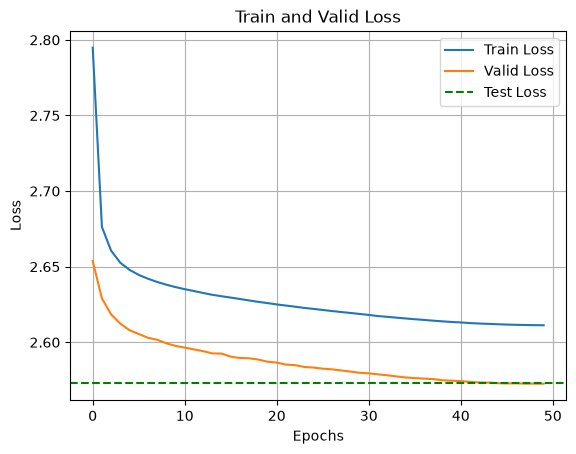

In [4]:
print(f"Model: {config.model.model_type}")
print(f"Test loss: {artifacts.test_loss:.4f}")
plot_loss(artifacts.history, test_loss=artifacts.test_loss, save_path=config.data.output_dir / "loss.png")

In [5]:
artifacts.model.generate(max_length=12)

'fukadinuz2ne'